# 🏠 House Price Prediction using Linear Regression
### Supervised Machine Learning
---

## Step 1 — Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


## Step 2 — Load Dataset

In [3]:
df = pd.read_csv('house_price_data.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (100, 8)


,Area_sqft,Bedrooms,Bathrooms,Age_years,Distance_to_city_km,Garage,Floors,Price_USD
0,3774,2,3,28,16.1,1,3,446385
1,4107,4,2,17,23.3,1,3,489543
2,1460,2,3,17,7.3,0,1,185140
3,1894,2,3,1,NaN,1,1,286522
4,1730,4,2,34,3.5,0,2,212784


## Step 3 — Exploratory Data Analysis (EDA)

In [4]:
# Basic statistics
df.describe()

,Area_sqft,Bedrooms,Bathrooms,Age_years,Distance_to_city_km,Garage,Floors,Price_USD
count,100.000000,100.000000,100.000000,100.000000,97.000000,100.000000,100.000000,100.000000
mean,2717.380000,2.980000,2.040000,21.440000,14.676289,0.420000,1.890000,328377.300000
std,1104.021197,1.476961,0.839913,11.001671,8.517332,0.496045,0.827495,134402.974694
min,621.000000,1.000000,1.000000,0.000000,1.400000,0.000000,1.000000,55418.000000
25%,1807.250000,1.750000,1.000000,14.000000,6.700000,0.000000,1.000000,210127.250000
50%,2791.500000,3.000000,2.000000,22.500000,14.800000,0.000000,2.000000,332383.500000
75%,3622.000000,4.000000,3.000000,31.000000,21.400000,1.000000,3.000000,439099.250000
max,4493.000000,5.000000,3.000000,39.000000,29.700000,1.000000,3.000000,578851.000000


In [5]:
# Check missing values
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
Area_sqft              0
Bedrooms               0
Bathrooms              0
Age_years              0
Distance_to_city_km    3
Garage                 0
Floors                 0
Price_USD              0
dtype: int64


In [6]:
# Fill missing values with column mean
df.fillna(df.mean(), inplace=True)
print('✅ Missing values filled with mean.')
print('Remaining missing values:', df.isnull().sum().sum())

✅ Missing values filled with mean.
Remaining missing values: 0


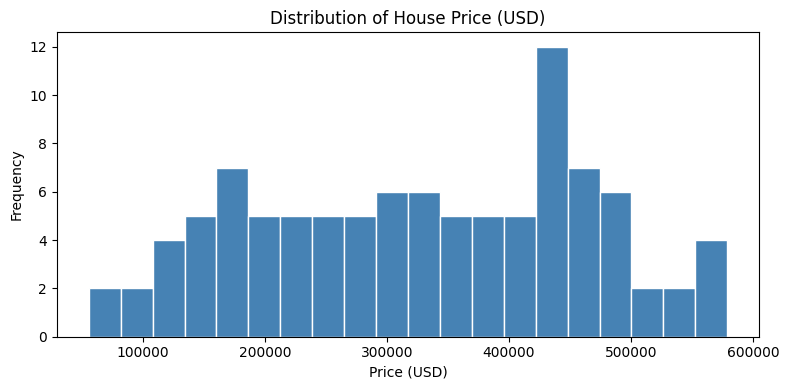

In [7]:
# Chart — Distribution of House Price (Target Variable)
plt.figure(figsize=(8, 4))
plt.hist(df['Price_USD'], bins=20, color='steelblue', edgecolor='white')
plt.title('Distribution of House Price (USD)')
plt.xlabel('Price (USD)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## Step 4 — Define Features & Target

In [8]:
features = ['Area_sqft', 'Bedrooms', 'Bathrooms', 'Age_years', 'Distance_to_city_km', 'Garage', 'Floors']

X = df[features]
y = df['Price_USD']

print(f'Features : {features}')
print(f'X shape  : {X.shape}')
print(f'y shape  : {y.shape}')

Features : ['Area_sqft', 'Bedrooms', 'Bathrooms', 'Age_years', 'Distance_to_city_km', 'Garage', 'Floors']
X shape  : (100, 7)
y shape  : (100,)


## Step 5 — Train/Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing samples  : {X_test.shape[0]}')

Training samples : 80
Testing samples  : 20


## Step 6 — Handle Missing Values in Test Data
> The **training set mean** is used to fill any missing values in test data — this prevents data leakage from test into train.

In [10]:
# Compute mean from training data only
train_means = X_train.mean()

# Apply to both sets
X_train = X_train.fillna(train_means)
X_test  = X_test.fillna(train_means)

print('✅ Missing values in test data filled using training mean.')
print('Train missing:', X_train.isnull().sum().sum())
print('Test missing :', X_test.isnull().sum().sum())

✅ Missing values in test data filled using training mean.
Train missing: 0
Test missing : 0


## Step 7 — Feature Scaling

In [11]:
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)  # fit on train, transform train
X_test  = scaler.transform(X_test)       # only transform test (no fit)

print('✅ Features scaled using StandardScaler (mean=0, std=1).')

✅ Features scaled using StandardScaler (mean=0, std=1).


## Step 8 — Train the Model

In [15]:
model = LinearRegression()
model.fit(X_train, y_train)

print('✅ Model trained!')
print(f'\nIntercept : {model.intercept_:,.2f}')

coef_df = pd.DataFrame({'Feature': features,            'Coefficient': model.coef_})
print('\nCoefficients:')
print(coef_df.to_string(index=False))

✅ Model trained!

Intercept : 333,429.67

Coefficients:
            Feature   Coefficient
          Area_sqft 128249.834226
           Bedrooms  22800.577570
          Bathrooms  10436.304349
          Age_years -26528.165385
Distance_to_city_km -27821.936315
             Garage   9719.024704
             Floors   7538.042419


## Step 9 — Evaluate the Model

In [13]:
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f'MAE  : ${mae:,.2f}')
print(f'RMSE : ${rmse:,.2f}')
print(f'R²   : {r2:.4f}')
print(f'\n📌 R² of {r2:.2f} means the model explains {r2*100:.1f}% of the variance in house prices.')

MAE  : $16,392.59
RMSE : $21,081.70
R²   : 0.9789

📌 R² of 0.98 means the model explains 97.9% of the variance in house prices.


## Formulas for Evaluation Metrics

**Mean Absolute Error (MAE):**
$$ \text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i| $$
- Measures the average absolute difference between predicted and actual values.
- Expressed in the same units as the target variable (e.g., USD for house prices).
- Less sensitive to outliers compared to RMSE.

**Root Mean Squared Error (RMSE):**
$$ \text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2} $$
- Measures the square root of the average squared differences between predicted and actual values.
- Penalizes larger errors more heavily due to squaring.
- Also expressed in the same units as the target variable.

Where:
- $y_i$ = actual house price
- $\hat{y}_i$ = predicted house price
- $n$ = number of test samples

## Step 10 — Predict on New Data

In [16]:
new_houses = pd.DataFrame({
    'Area_sqft'           : [1500, 3000],
    'Bedrooms'            : [2,    4   ],
    'Bathrooms'           : [1,    3   ],
    'Age_years'           : [10,   5   ],
    'Distance_to_city_km' : [15,   8   ],
    'Garage'              : [0,    1   ],
    'Floors'              : [1,    2   ]
})

# Fill any missing using training mean, then scale
new_houses_filled = new_houses.fillna(train_means)
new_scaled        = scaler.transform(new_houses_filled)

predictions = model.predict(new_scaled).astype(int)
new_houses['Predicted_Price_USD'] = predictions

print('🏡 Predicted Prices:')
print(new_houses.to_string(index=False))

🏡 Predicted Prices:
 Area_sqft  Bedrooms  Bathrooms  Age_years  Distance_to_city_km  Garage  Floors  Predicted_Price_USD
      1500         2          1         10                   15       0       1               164593
      3000         4          3          5                    8       1       2               464053
